This file is meant to test a few issues I see in the main analysis such as seemingly missing data that 

In [1]:
import sqlite3 as sql
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import StatsFunc
con = sql.connect("nba.sqlite")
cur = con.cursor()

# Missing Hawks and Celtics Data

The Celtics and Hawks are missing assist and rebound data until the 70s, at least for the most part. For whatever reason, the SQLite file has sporadic data for the pre-70s and I am curious as to what is going on: whether it is an issue with my query's aggregation of the data or if it is an issue with the data file itself (null data for example).

In [50]:
query = "SELECT COUNT(DISTINCT game_date) FROM game WHERE SUBSTRING(season_id,2,5) ='1955' AND (team_abbreviation_home = \'BOS\' OR team_abbreviation_away = \'BOS\')"
cur.execute(query)
cur.fetchall()

[(74,)]

In [4]:
query = """SELECT SUBSTRING(season_id,2,5) AS Season, game_date,
    CASE WHEN team_abbreviation_home = \'ATL\' THEN pts_home WHEN team_abbreviation_away = \'ATL\' THEN pts_away END AS 'Team Points',
    CASE WHEN team_abbreviation_home = \'ATL\' THEN ast_home WHEN team_abbreviation_away = \'ATL\' THEN ast_away END AS 'Team Assists',
    CASE WHEN team_abbreviation_home = \'ATL\' THEN reb_home WHEN team_abbreviation_away = \'ATL\' THEN reb_away END AS 'Team Rebounds'
    FROM game
    WHERE Season ='1968' AND (team_abbreviation_home = \'ATL\' OR team_abbreviation_away = \'ATL\')"""

cur.execute(query)
cur.fetchall()

[('1968', '1968-10-16 00:00:00', 110.0, None, None),
 ('1968', '1968-10-19 00:00:00', 125.0, None, None),
 ('1968', '1968-10-23 00:00:00', 106.0, None, None),
 ('1968', '1968-10-25 00:00:00', 112.0, None, None),
 ('1968', '1968-10-27 00:00:00', 123.0, None, None),
 ('1968', '1968-10-29 00:00:00', 124.0, None, None),
 ('1968', '1968-10-30 00:00:00', 116.0, None, None),
 ('1968', '1968-11-01 00:00:00', 109.0, None, None),
 ('1968', '1968-11-03 00:00:00', 103.0, None, None),
 ('1968', '1968-11-06 00:00:00', 119.0, None, None),
 ('1968', '1968-11-08 00:00:00', 114.0, None, None),
 ('1968', '1968-11-09 00:00:00', 113.0, None, None),
 ('1968', '1968-11-12 00:00:00', 108.0, None, None),
 ('1968', '1968-11-13 00:00:00', 142.0, None, None),
 ('1968', '1968-11-15 00:00:00', 115.0, None, None),
 ('1968', '1968-11-16 00:00:00', 125.0, None, None),
 ('1968', '1968-11-19 00:00:00', 98.0, None, None),
 ('1968', '1968-11-20 00:00:00', 111.0, None, None),
 ('1968', '1968-11-21 00:00:00', 129.0, None, N

In [5]:
query = """SELECT SUBSTRING(season_id,2,5) AS Season, game_date,
    CASE WHEN team_abbreviation_home = \'BOS\' THEN pts_home WHEN team_abbreviation_away = \'BOS\' THEN pts_away END AS 'Team Points',
    CASE WHEN team_abbreviation_home = \'BOS\' THEN ast_home WHEN team_abbreviation_away = \'BOS\' THEN ast_away END AS 'Team Assists',
    CASE WHEN team_abbreviation_home = \'BOS\' THEN reb_home WHEN team_abbreviation_away = \'BOS\' THEN reb_away END AS 'Team Rebounds'
    FROM game
    WHERE Season ='1955' AND (team_abbreviation_home = \'BOS\' OR team_abbreviation_away = \'BOS\')"""

cur.execute(query)
cur.fetchall()

[('1955', '1955-11-05 00:00:00', 98.0, None, None),
 ('1955', '1955-11-12 00:00:00', 119.0, None, None),
 ('1955', '1955-11-12 00:00:00', 95.0, None, None),
 ('1955', '1955-11-17 00:00:00', 92.0, None, None),
 ('1955', '1955-11-19 00:00:00', 104.0, None, None),
 ('1955', '1955-11-23 00:00:00', 111.0, None, None),
 ('1955', '1955-11-24 00:00:00', 103.0, None, None),
 ('1955', '1955-11-26 00:00:00', 104.0, None, None),
 ('1955', '1955-11-29 00:00:00', 105.0, None, None),
 ('1955', '1955-12-02 00:00:00', 94.0, None, None),
 ('1955', '1955-12-04 00:00:00', 90.0, None, None),
 ('1955', '1955-12-06 00:00:00', 122.0, None, None),
 ('1955', '1955-12-09 00:00:00', 108.0, None, None),
 ('1955', '1955-12-10 00:00:00', 118.0, None, None),
 ('1955', '1955-12-11 00:00:00', 89.0, None, None),
 ('1955', '1955-12-13 00:00:00', 108.0, None, None),
 ('1955', '1955-12-14 00:00:00', 102.0, None, None),
 ('1955', '1955-12-17 00:00:00', 104.0, None, None),
 ('1955', '1955-12-18 00:00:00', 95.0, None, None),


In [49]:
query = """SELECT SUBSTRING(season_id,2,5) AS Season, game_date,
    CASE WHEN team_abbreviation_home = \'BOS\' THEN ast_home WHEN team_abbreviation_away = \'BOS\' THEN ast_away END AS 'Team Assists',
    CASE WHEN team_abbreviation_home = \'BOS\' THEN ast_away WHEN team_abbreviation_away = \'BOS\' THEN ast_home END AS 'Opp Assists'
    FROM game WHERE Season BETWEEN '1950'  AND '1960' AND (ast_home <> '' OR ast_away <> '') AND (team_abbreviation_home = \'BOS\' OR team_abbreviation_away = \'BOS\')"""
cur.execute(query)
cur.fetchall()


[('1950', '1951-03-22 00:00:00', 20.0, 23.0),
 ('1951', '1951-11-24 00:00:00', 18.0, 20.0),
 ('1954', '1954-12-29 00:00:00', 0.0, 0.0),
 ('1954', '1955-03-15 00:00:00', 0.0, 0.0)]

It seems as though data is just missing for some of these statistics, which is likely to continue for the other 28 teams.

# Next

In [2]:
query = "SELECT abbreviation FROM team_details"
cur.execute(query)
teams = cur.fetchall()
teams = ['\'' + i[0] + '\'' for i in teams]
query = "SELECT nickname FROM team_details"
cur.execute(query)
teamDFs = cur.fetchall()
teamDFs = [i[0] for i in teamDFs]
DataFrame_Dict = {}
for i,team in enumerate(teams):
  DataFrame_Dict[teamDFs[i]] = StatsFunc.get_team_stats(con, team)
LeagueDF = StatsFunc.get_league_stats(con)
LeagueDF.head()
HawksDF = DataFrame_Dict["Hawks"]
HawksDF.head()


,Team Points,Team Assists,Team Total Rebounds,Team Offensive Rebounds,Team Defensive Rebounds,Team Steals,Team Blocks,Team Turnovers,Team Personal Fouls,Team Field Goals Attempted,Team Field Goals Made,Team 3-pt Field Goals Attempted,Team 3-pt Field Goals Made,Team Free Throws Attempted,Team Free Throws Made,Team Plus Minus
Season,,,,,,,,,,,,,,,,
1968,111.865854,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.987805,NaN,43.939024,NaN,NaN,34.292683,23.987805,3.426829
1969,118.835165,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.900000,NaN,47.318681,NaN,NaN,32.274725,24.197802,3.461538
1970,108.800000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.400000,NaN,43.600000,NaN,NaN,29.000000,21.600000,3.000000
1971,108.988636,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.875000,NaN,42.227273,NaN,NaN,32.693182,24.534091,-3.772727
1972,110.909091,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.284091,NaN,45.102273,NaN,NaN,27.579545,20.704545,-2.727273


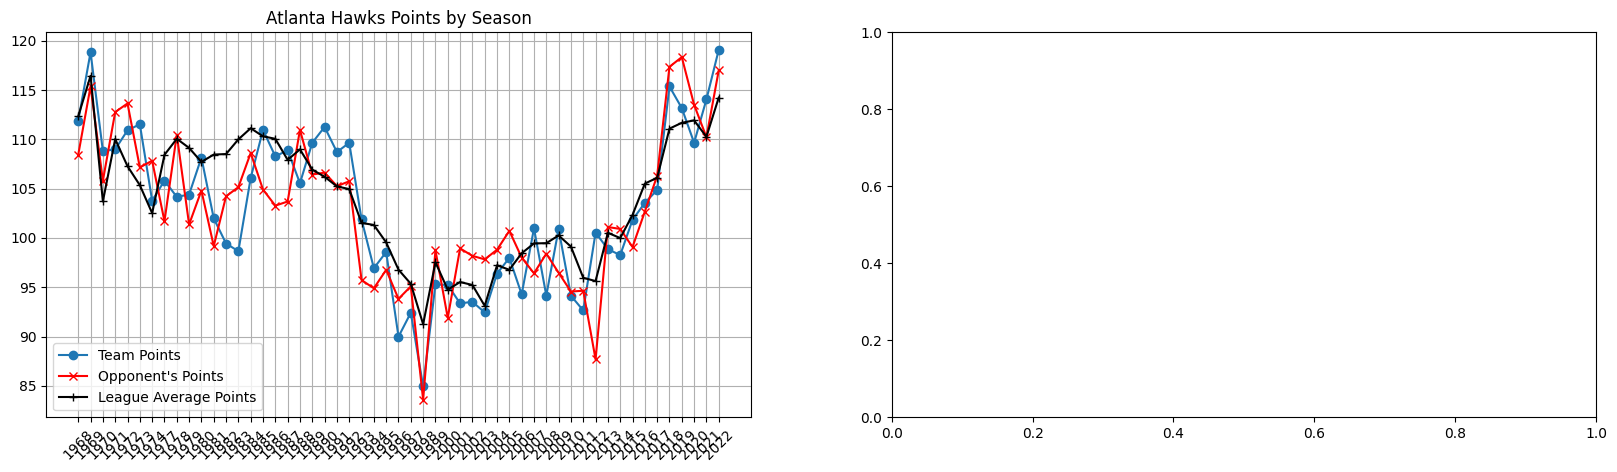

In [ ]:
fig, (ax1, ax2) = plt.subplots(nrows = 1, ncols = 2, figsize=(20,5))
ax1.set_title("Atlanta Hawks Points by Season")
ax1.grid('both', 'both')
ax1.tick_params("x", rotation=45)
ax1.plot(HawksDF.index, HawksDF["Team Points"], label="Team Points", marker='o')
ax1.plot(HawksDF.index, HawksDF["Team Points"] - HawksDF["Team Plus Minus"], c='red', marker='x', label="Opponent's Points")
ax1.plot(HawksDF.index, LeagueDF["League Points"].loc[HawksDF.index], c='black', marker='+', label="League Average Points")
ax1.legend()